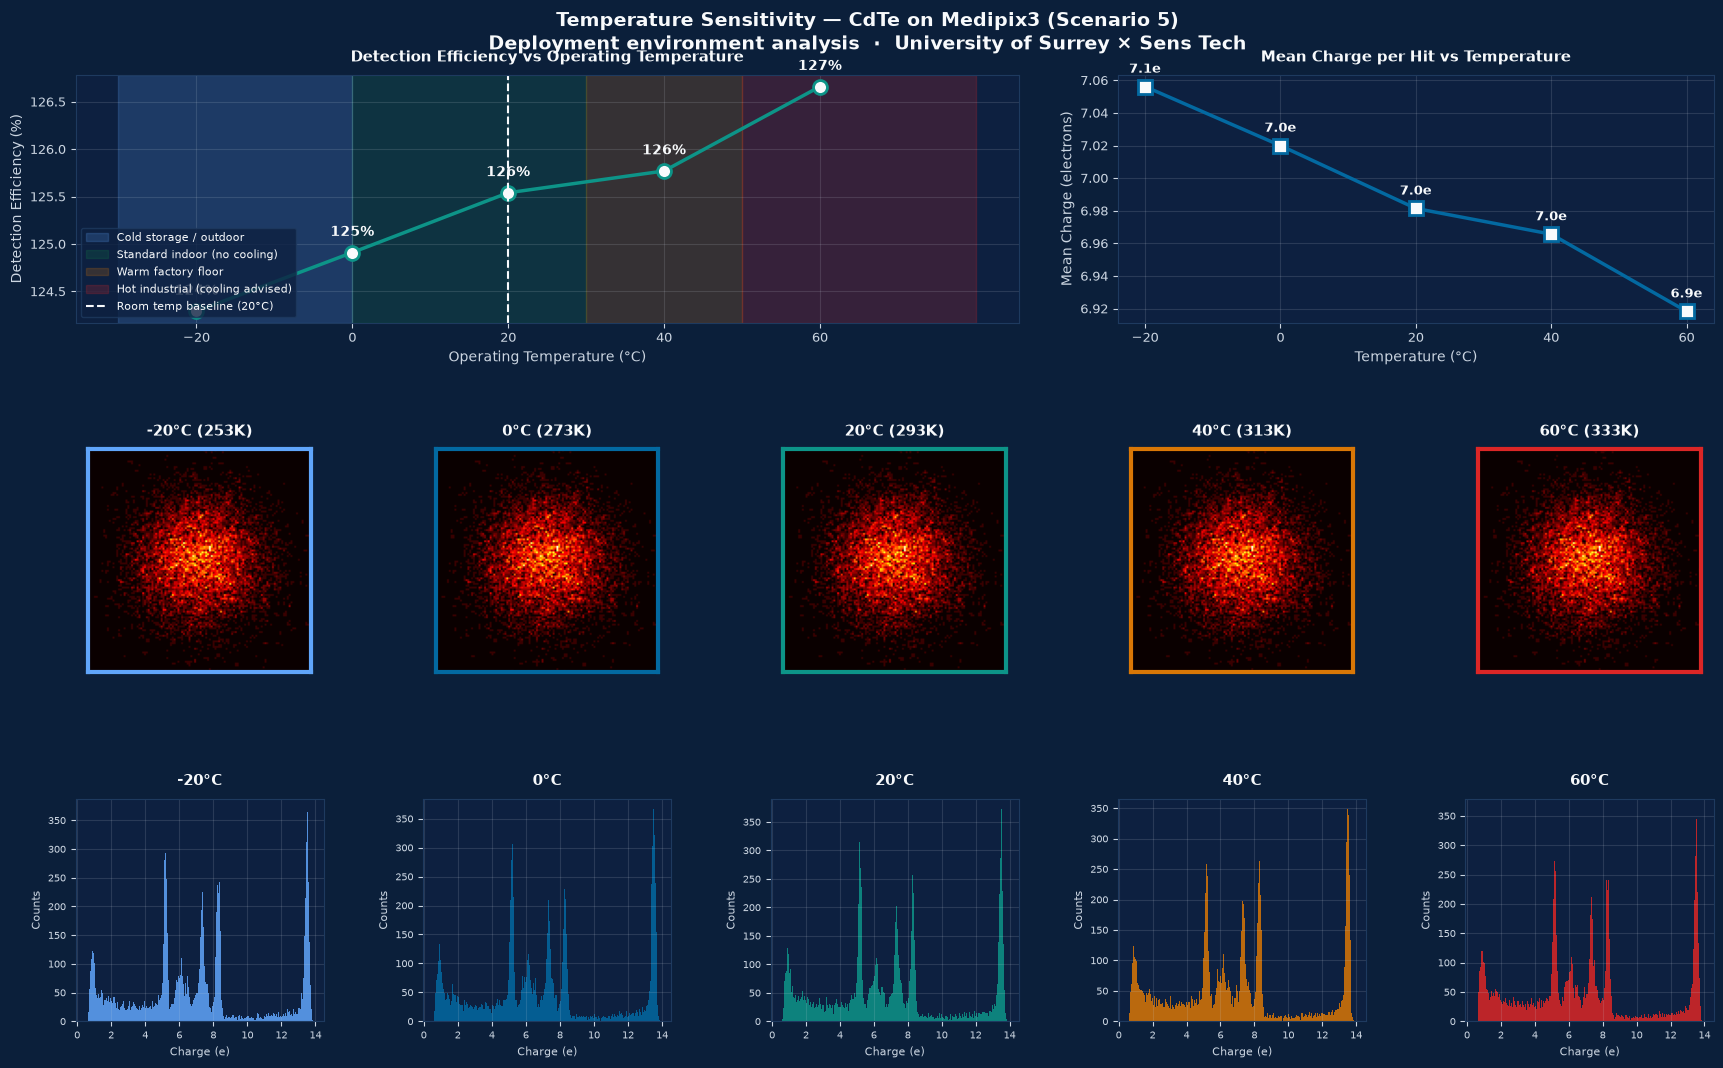

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/s5_temperature_dashboard.png

── Summary ───────────────────────────────────
  -20°C (253K) → 12,429 hits | 124.3% | mean charge 7.1e
    0°C (273K) → 12,491 hits | 124.9% | mean charge 7.0e
   20°C (293K) → 12,554 hits | 125.5% | mean charge 7.0e
   40°C (313K) → 12,577 hits | 125.8% | mean charge 7.0e
   60°C (333K) → 12,666 hits | 126.7% | mean charge 6.9e


In [1]:
"""
Scenario 5 — Temperature Sensitivity Dashboard
Deployment environment analysis — does the detector need cooling?
"""

import os
os.environ["QT_QPA_PLATFORM"] = "xcb"

import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BASE = os.path.expanduser("~/itek/senstech-simulation/data")
DET = "medipix3_detector"

temps_K = [253, 273, 293, 313, 333]
temps_C = [T - 273 for T in temps_K]
n_events = 10000

results = []
hit_maps = []
charge_specs = []

for T in temps_K:
    path = os.path.join(BASE, f"s5_cdte_{T}K.root")
    f = uproot.open(path)
    pc = f[f"DetectorHistogrammer/{DET}/charge/pixel_charge;1"].to_numpy()
    hm = f[f"DetectorHistogrammer/{DET}/hit_map;1"].to_numpy()
    cs = f[f"DetectorHistogrammer/{DET}/cluster_size/cluster_size;1"].to_numpy()

    hits = int(pc[0].sum())
    mean_q = np.average(pc[1][:-1], weights=pc[0] + 1e-9)
    mean_cs = np.average(cs[1][:-1], weights=cs[0] + 1e-9)

    results.append({"temp_K": T, "temp_C": T - 273, "hits": hits,
                    "efficiency": (hits / n_events) * 100,
                    "mean_charge": mean_q, "mean_cluster": mean_cs})
    hit_maps.append(hm[0])
    charge_specs.append(pc)

NAVY, WHITE, LGRAY = "#0B1F3A", "#F8FAFC", "#CBD5E1"
TEAL, BLUE, AMBER, RED, ICE = "#0D9488", "#0369A1", "#D97706", "#DC2626", "#60A5FA"

def style_ax(ax, title):
    ax.set_facecolor("#0D2040")
    ax.tick_params(colors=LGRAY, labelsize=9)
    ax.xaxis.label.set_color(LGRAY); ax.yaxis.label.set_color(LGRAY)
    ax.title.set_color(WHITE)
    ax.set_title(title, fontweight="bold", fontsize=11, pad=10)
    for s in ax.spines.values(): s.set_edgecolor("#1E3A5F")
    ax.grid(True, alpha=0.15, color=LGRAY)

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor(NAVY)
gs = gridspec.GridSpec(3, 5, figure=fig, hspace=0.55, wspace=0.4,
                       left=0.06, right=0.97, top=0.92, bottom=0.06,
                       height_ratios=[1, 0.9, 0.9])

# Main efficiency curve with environment zones
ax1 = fig.add_subplot(gs[0, :3])
style_ax(ax1, "Detection Efficiency vs Operating Temperature")
effs = [r["efficiency"] for r in results]
ax1.plot(temps_C, effs, color=TEAL, linewidth=2.5, marker="o", markersize=10,
         markerfacecolor=WHITE, markeredgewidth=2)
# Environment zones
ax1.axvspan(-30, 0, alpha=0.2, color=ICE, label="Cold storage / outdoor")
ax1.axvspan(0, 30, alpha=0.15, color="#16A34A", label="Standard indoor (no cooling)")
ax1.axvspan(30, 50, alpha=0.2, color=AMBER, label="Warm factory floor")
ax1.axvspan(50, 80, alpha=0.2, color=RED, label="Hot industrial (cooling advised)")
ax1.axvline(x=20, color=WHITE, linestyle="--", linewidth=1.5,
            label="Room temp baseline (20°C)")
for r in results:
    ax1.annotate(f"{r['efficiency']:.0f}%", xy=(r["temp_C"], r["efficiency"]),
                 xytext=(0, 12), textcoords="offset points", ha="center",
                 color=WHITE, fontsize=10, fontweight="bold")
ax1.set_xlabel("Operating Temperature (°C)")
ax1.set_ylabel("Detection Efficiency (%)")
ax1.set_xticks(temps_C)
ax1.legend(loc="lower left", fontsize=8, labelcolor=WHITE,
           facecolor="#0D2040", edgecolor="#1E3A5F")

# Mean charge per hit vs temperature
ax2 = fig.add_subplot(gs[0, 3:])
style_ax(ax2, "Mean Charge per Hit vs Temperature")
charges = [r["mean_charge"] for r in results]
ax2.plot(temps_C, charges, color=BLUE, linewidth=2.5, marker="s", markersize=10,
         markerfacecolor=WHITE, markeredgewidth=2)
for r in results:
    ax2.annotate(f"{r['mean_charge']:.1f}e", xy=(r["temp_C"], r["mean_charge"]),
                 xytext=(0, 10), textcoords="offset points", ha="center",
                 color=WHITE, fontsize=9, fontweight="bold")
ax2.set_xlabel("Temperature (°C)")
ax2.set_ylabel("Mean Charge (electrons)")
ax2.set_xticks(temps_C)

# Hit maps
colors = [ICE, "#0369A1", TEAL, AMBER, RED]
for i, (T_K, T_C) in enumerate(zip(temps_K, temps_C)):
    ax = fig.add_subplot(gs[1, i])
    style_ax(ax, f"{T_C}°C ({T_K}K)")
    hm = hit_maps[i]
    c = hm.shape[0] // 2; cr = 60
    ax.imshow(hm[c-cr:c+cr, c-cr:c+cr], cmap="hot", origin="lower",
              aspect="equal", vmax=max(h.max() for h in hit_maps))
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor(colors[i]); s.set_linewidth(3)

# Charge spectra
for i, T_C in enumerate(temps_C):
    ax = fig.add_subplot(gs[2, i])
    style_ax(ax, f"{T_C}°C")
    vals = charge_specs[i]
    m = vals[0] > 0
    ax.bar(vals[1][:-1][m], vals[0][m], width=np.diff(vals[1])[m],
           color=colors[i], alpha=0.85)
    ax.set_xlabel("Charge (e)", fontsize=8)
    ax.set_ylabel("Counts", fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle("Temperature Sensitivity — CdTe on Medipix3 (Scenario 5)\n"
             "Deployment environment analysis  ·  University of Surrey × Sens Tech",
             fontsize=14, fontweight="bold", color=WHITE, y=0.98)

out = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks/s5_temperature_dashboard.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

print("\n── Summary ───────────────────────────────────")
for r in results:
    print(f"  {r['temp_C']:>3}°C ({r['temp_K']}K) → {r['hits']:>6,} hits | "
          f"{r['efficiency']:>5.1f}% | mean charge {r['mean_charge']:.1f}e")